In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

### Excercise 11.1

In [8]:
df_E1101 = pd.DataFrame({
    'reflux': [6.7,6.7,6.9,7.1,7.1,5.9,5.9,6.3,6.7,6.7,5.9,5.9,6.3,6.7,6.7],
    'recycle': [8.0,7.5,7.75,8.0,7.5,8.5,8.0,8.25,8.5,8.0,8.75,8.25,8.5,8.75,8.25],
    'cost': [86,92,92,91,95,80,83,82,81,84,86,84,80,85,83]
})

[Text(6.7, 8.0, '86'),
 Text(6.7, 7.5, '92'),
 Text(6.9, 7.75, '92'),
 Text(7.1, 8.0, '91'),
 Text(7.1, 7.5, '95'),
 Text(5.9, 8.5, '80'),
 Text(5.9, 8.0, '83'),
 Text(6.3, 8.25, '82'),
 Text(6.7, 8.5, '81'),
 Text(6.7, 8.0, '84'),
 Text(5.9, 8.75, '86'),
 Text(5.9, 8.25, '84'),
 Text(6.3, 8.5, '80'),
 Text(6.7, 8.75, '85'),
 Text(6.7, 8.25, '83')]

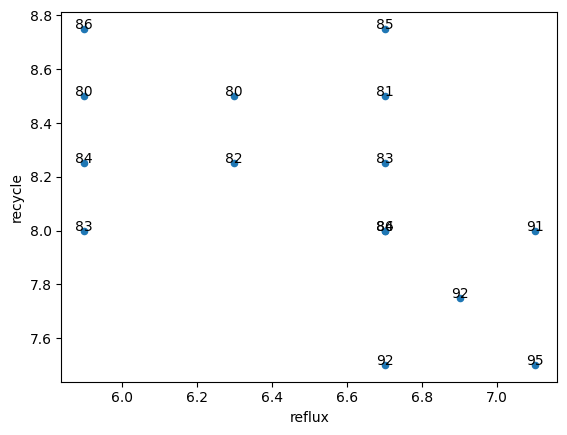

In [9]:
ax_E1101 = df_E1101.plot.scatter(x='reflux', y='recycle')
[ax_E1101.text(x,y,s,ha='center') for x,y,s in zip(df_E1101.reflux, df_E1101.recycle, df_E1101.cost)]

### Table 11A.1

In [3]:
df_T11A1 = pd.DataFrame({
    'setup': np.arange(16)+1,
    'seat_height': [_ for _ in '--++--++--++--++'],
    'generator': [_ for _ in '----++++----++++'],
    'tire_p': [_ for _ in '--------++++++++'],
    'pulse_before': [76,76,76,79,77,77,76,79,76,80,77,78,78,79,80,77],
    'pulse_after': [135,133,132,137,134,133,130,139,105,144,139,139,137,125,122,133],
    'time': [51,54,41,43,54,60,44,43,50,48,39,39,53,51,41,44],

})

In [5]:
factors_T11A1 = ['seat_height', 'generator', 'tire_p']
factor_cms_T11A1 = []
from itertools import combinations
for r in range(3):
    factor_cms_T11A1.extend(combinations(factors_T11A1, r+1))

factor_cms_T11A1

[('seat_height',),
 ('generator',),
 ('tire_p',),
 ('seat_height', 'generator'),
 ('seat_height', 'tire_p'),
 ('generator', 'tire_p'),
 ('seat_height', 'generator', 'tire_p')]

In [21]:
effects_T11A1 = dict()
for factor_cm in factor_cms_T11A1:
    n = len(factor_cm)
    effct = '_'.join(factor_cm)
    effects_T11A1[effct] = df_T11A1.groupby(list(factor_cm))['time'].mean()
    for i in range(n):
        effects_T11A1[effct] = effects_T11A1[effct].diff(-1* 2**i)
        if i!=0:
            effects_T11A1[effct] = effects_T11A1[effct]/2
    effects_T11A1[effct] = effects_T11A1[effct].values[0]

effects_T11A1

{'seat_height': np.float64(-10.875),
 'generator': np.float64(3.125),
 'tire_p': np.float64(-3.125),
 'seat_height_generator': np.float64(-0.625),
 'seat_height_tire_p': np.float64(1.125),
 'generator_tire_p': np.float64(0.125),
 'seat_height_generator_tire_p': np.float64(0.875)}

In [ ]:
df_T11A1.groupby(['seat_height', 'generator', 'tire_p'])['time'].var(ddof=1).sum() * 1 / 8 # variance of within treatment, experiment variance

np.float64(4.1875)

In [38]:
# variance of effect
4/16 * 4.1875

1.046875

In [39]:
# standard error of effect
np.sqrt(4/16*4.1875)

np.float64(1.0231690964840563)

[Text(-10.875, 0.03, 'seat_height'),
 Text(3.125, 0.03, 'generator'),
 Text(-3.125, 0.03, 'tire_p'),
 Text(-0.625, 0.03, 'seat_height_generator'),
 Text(1.125, 0.03, 'seat_height_tire_p'),
 Text(0.125, 0.03, 'generator_tire_p'),
 Text(0.875, 0.03, 'seat_height_generator_tire_p')]

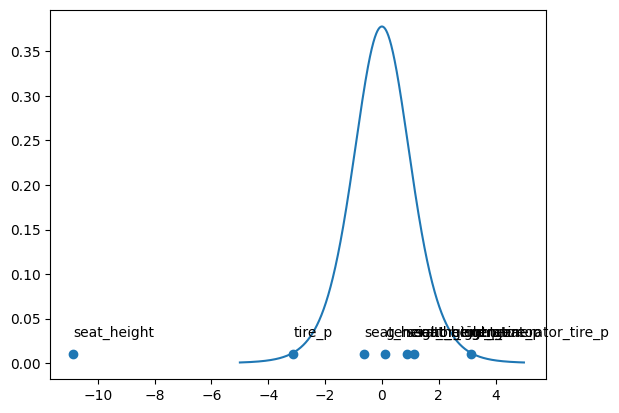

In [63]:
range_T11A1 = 5
x_T11A1 = np.linspace(-range_T11A1, range_T11A1, 1001)
plt.plot(x_T11A1, stats.t.pdf(x_T11A1, scale=np.sqrt(4.1875/4), df=8))
plt.scatter(effects_T11A1.values(), [0.01]*7)
[plt.text(x,y,s) for x,y,s in zip(effects_T11A1.values(), [0.03]*7, effects_T11A1.keys())]